<h2 style="color:blue" align="center">Boston Housing Price Prediction</h2>

#### Import the necessary libraries

In [73]:
import os
import random 
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import MinMaxScaler 

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

#### Load and split the dataset into training and testing set

In [74]:
# Define the source URL
data_url = "http://lib.stat.cmu.edu/datasets/boston"

# Load the raw data
# The file has a complex structure where data points are split across lines
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# Process the data to fix the "split row" issue
# Stack every even row (0, 2, 4...) with the first 2 columns of every odd row (1, 3, 5...)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Define the standard column names for Boston Housing
columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

# Create a combined DataFrame for display purposes
df = pd.DataFrame(data, columns=columns)
df['MEDV'] = target  # Add the target column

print("Data Loaded Successfully.")

Data Loaded Successfully.


In [75]:
# Display the first 5 rows
print(df.head())

# Optional: Check the shape to ensure we have 506 rows and 14 columns
print("\nDataset Shape:", df.shape)

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Dataset Shape: (506, 14)


#### Preprocess the dataset

In [76]:
# Check if there are any NaNs in the dataset
print("Missing values before drop:\n", df.isnull().sum())

# Drop any row that contains at least one NaN value
df_clean = df.dropna()

# Verify the shape change
print(f"\nOriginal Shape: {df.shape}")
print(f"Clean Shape:    {df_clean.shape}")

Missing values before drop:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Original Shape: (506, 14)
Clean Shape:    (506, 14)


#### Split into Train and Test Sets (80:20)

In [77]:
# Separate Features (X) and Target (y)
X = df_clean.drop('MEDV', axis=1).values
y = df_clean['MEDV'].values

# Split the data: 80% Training, 20% Testing
# random_state=42 ensures the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples:  {X_test.shape[0]}")

Training Samples: 404
Testing Samples:  102


#### Normalize the input dataset

In [78]:
# 1. Normalize Features (X)
mms_x = MinMaxScaler()
X_train_norm = mms_x.fit_transform(X_train)
X_test_norm = mms_x.transform(X_test)  # Transform test using train scaler

# 2. Normalize Targets (y)
# Reshape is necessary because Scaler expects 2D array (n_samples, 1)
mms_y = MinMaxScaler()
y_train_norm = mms_y.fit_transform(y_train.reshape(-1, 1))
y_test_norm = mms_y.transform(y_test.reshape(-1, 1))

# 3. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_norm, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_norm, dtype=torch.float32)

# Verify
print(f"X_train shape: {X_train_tensor.shape}")
print(f"y_train shape: {X_test_tensor.shape}") 

X_train shape: torch.Size([404, 13])
y_train shape: torch.Size([102, 13])


#### Define Linear Regression model

##### Seed random

In [79]:
def set_seed(seed=42):
    """
    Set seeds for reproducibilit    
    Args:
        seed: Random seed
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

##### Define the model and optimizer

In [93]:
def get_model_and_optimizer(opti_name='SGD', learning_rate=0.0001):
    
    # 1. Define Model
    # Equivalent to: Sequential([Dense(1, input_dim=13, activation='linear')])
    model = nn.Sequential(
        nn.Linear(13, 1) 
    )
    
    # 2. Define Optimizer
    # Note: PyTorch optimizers require the model parameters as input
    
    if opti_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
        
    elif opti_name == 'Momentum':
        # Equivalent to SGD with momentum
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
        
    elif opti_name == 'NAG':
        # Nesterov Accelerated Gradient
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, nesterov=True)
        
    elif opti_name == 'AdaGrad':
        optimizer = optim.Adagrad(model.parameters(), lr=learning_rate)
        
    elif opti_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
        
    elif opti_name == 'AdaDelta':
        optimizer = optim.Adadelta(model.parameters(), lr=learning_rate)
        
    elif opti_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        
    elif opti_name == 'AdaMax':
        optimizer = optim.Adamax(model.parameters(), lr=learning_rate)
        
    elif opti_name == 'NAdam':
        optimizer = optim.NAdam(model.parameters(), lr=learning_rate)
        
    # Additional optimizers from our previous context (included for completeness)
    elif opti_name == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    elif opti_name == 'RAdam':
        optimizer = optim.RAdam(model.parameters(), lr=learning_rate)
    elif opti_name == 'ASGD':
        optimizer = optim.ASGD(model.parameters(), lr=learning_rate)
    elif opti_name == 'Rprop':
        optimizer = optim.Rprop(model.parameters(), lr=learning_rate)
        
    else:
        raise ValueError(f"Optimizer {opti_name} not found.")

    # 3. Define Loss Function
    # Equivalent to loss='mse'
    criterion = nn.MSELoss()
    
    return model, optimizer, criterion

#### HMS

In [94]:
# per iteration wise
class HMSHandler:
    def __init__(self, model, r=1, t=100):
        self.model = model
        self.r, self.t = r, t
        # Initialize previous weights (detached from graph)
        self.prev_w = [p.data.clone() for p in model.parameters()]

    def update_weights(self):
        """Applies Harmonic Mean update to weights (Call this every BATCH)."""
        with torch.no_grad():
            for i, p in enumerate(self.model.parameters()):
                v1, v2 = self.prev_w[i], p.data
                denom = v1.abs() + v2.abs()
                zero_mask = (v1 == 0) | (v2 == 0) | (denom == 0)
                
                # Calculate Harmonic Mean
                hm = torch.zeros_like(v1)
                hm[~zero_mask] = (2 * v1[~zero_mask].abs() * v2[~zero_mask].abs()) / denom[~zero_mask]
                
                # Calculate HMS adjustment
                hms = (hm - torch.min(v1.abs(), v2.abs())).abs() * self.r
                mask_pos, mask_neg = (v1 > v2), (v1 < v2)
                
                # Update current weights
                p.data[mask_pos] -= hms[mask_pos]
                p.data[mask_neg] += hms[mask_neg]
                
                # Update 'previous' weights for the next iteration
                self.prev_w[i] = p.data.clone()

    def decay_r(self, epoch):
        """Decays the r factor (Call this every EPOCH)."""
        if (epoch + 1) % self.t == 0: 
            self.r = round(self.r * 0.9, 4)

#### Traning loop

In [95]:
# per iteration wise
def train_engine(model, optimizer, criterion, loader, epochs, log_file, use_hms=False, r=1, t=100):
    # Initialize Handler
    hms = HMSHandler(model, r, t) if use_hms else None
    loss_history = []
    start_time = time.time()
    
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        # --- Batch Loop ---
        for xb, yb in loader: 
            
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            
            # Apply HMS Weight Update Every Batch
            if use_hms: 
                hms.update_weights()
            
            epoch_loss += loss.item() * xb.size(0)
        
        # Apply HMS Decay Every Epoch
        if use_hms: 
            hms.decay_r(epoch)

        # Log metrics (mimicking CSVLogger)           
        loss_history.append({'epoch': epoch, 'loss': epoch_loss})

    end_time = time.time()
    
    # Save logs to CSV
    pd.DataFrame(loss_history).to_csv(log_file, index=False)
    
    execution_time = round(end_time - start_time, 4)
        
    return loss_history

#### Training

##### Configuration parameters

In [96]:
# 3. Setup Training Parameters
num_epochs = 1000

# Assuming X_train_tensor was created in the previous data loading step
Full = X_train_tensor.shape[0] 

# Set batch size
batch_size = 32  # Options: Full, 256, 64, 16

# --- Setup Data Loaders ---
# Assuming X_train_tensor and y_train_tensor exist from previous steps
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# --- Initialize Weights Separately ---
# We create a "master" copy of initial weights to ensure FAIR comparison
optimizer_name = 'Momentum'
# 'SGD','Momentum','NAG','AdaGrad','RMSprop','AdaDelta','Adam','AdaMax','NAdam','AdamW','RAdam','ASGD','Rprop'

# --- Create Directory if it doesn't exist ---
result_dir = 'Deep_learning_results'
os.makedirs(result_dir, exist_ok=True)  # Creates all missing folders safely

# --- Define File Names ---
generic_file = f'{result_dir}/{optimizer_name}_optimizer.csv'
hms_file = f'{result_dir}/{optimizer_name}_HMS_optimizer.csv'

master_model, _, _ = get_model_and_optimizer() # Using the function from previous steps
initial_state = copy.deepcopy(master_model.state_dict())

##### Running the model

In [97]:
# per iteration wise
# ==========================================
# 1. Train Generic Model (Without HMS)
# ==========================================
print("Training Generic Model...")
model_generic, optimizer_generic, criterion = get_model_and_optimizer(optimizer_name)
model_generic.load_state_dict(copy.deepcopy(initial_state)) 

# Measure time manually
st = time.time()
hist_generic = train_engine(
    model_generic, 
    optimizer_generic, 
    criterion, 
    train_loader, 
    num_epochs,  
    generic_file, 
    use_hms=False
)
et = time.time()
elapsed_training_time_generic = round(et - st, 4)

# (Optional) Save the log file here if needed
pd.DataFrame(hist_generic).to_csv(generic_file, index=False)

print('Execution time (Generic):', elapsed_training_time_generic, 'seconds')

# ==========================================
# 2. Train HMS Model (With HMS)
# ==========================================
print("\nTraining HMS Model...")
model_hms, optimizer_hms, criterion = get_model_and_optimizer(optimizer_name)
model_hms.load_state_dict(copy.deepcopy(initial_state)) 

st = time.time()
hist_hms = train_engine(
    model_hms, 
    optimizer_hms, 
    criterion, 
    train_loader, 
    num_epochs,
    hms_file, 
    use_hms=True, 
)
et = time.time()
elapsed_training_time_hms = round(et - st, 4)

# (Optional) Save the log file here if needed
pd.DataFrame(hist_hms).to_csv(hms_file, index=False)

print('Execution time (HMS):', elapsed_training_time_hms, 'seconds')

Training Generic Model...
Execution time (Generic): 4.0846 seconds

Training HMS Model...
Execution time (HMS): 7.4663 seconds


#### Generic optimizer vs HMS-based optimizer

In [98]:
df1 = pd.read_csv(generic_file)
df2 = pd.read_csv(hms_file)

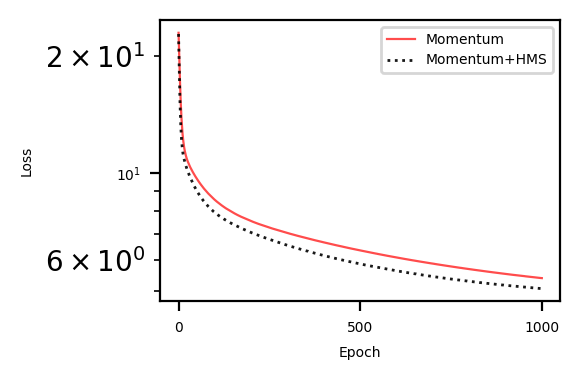

In [99]:
x1 = range(0, df1.shape[0])
x2 = range(0, df2.shape[0])
y1 = df1['loss'] 
y2 = df2['loss']  
plt.figure(figsize = (3,2), dpi = 200)
plt.plot(x1, y1, "r-", label = optimizer_name, linewidth = 0.8, alpha = 0.7)
plt.plot(x2, y2, "k:", label = optimizer_name+'+HMS', linewidth = 1, alpha = 0.9) 
plt.ylabel('Loss' , fontdict = {'fontsize':5})
plt.xlabel('Epoch', fontdict = {'fontsize':5}) 
plt.yscale('log')
#plt.title("Loss", fontdict = {'fontname':'Times New Roman', 'fontsize':8})
plt.xticks(fontsize = 5)
plt.yticks(fontsize = 5)
plt.tight_layout()
plt.legend(prop={'size': 5})
#plt.savefig("graph.png",bbox_inches='tight',dpi=(300)) 
plt.show()

#### Training cost

In [100]:
print(f'Taining cost on {optimizer_name} = {round(df1.iloc[num_epochs-1].loss, 5)}')
print(f'Taining cost on {optimizer_name}+HMS = {round(df2.iloc[num_epochs-1].loss, 5)}')

Taining cost on Momentum = 5.39763
Taining cost on Momentum+HMS = 5.07333


#### Testing the model

In [101]:
def evaluate_model(model, criterion, X_data, y_data):
    """
    Evaluates the model on the given data using the specified loss criterion.
    """
    model.eval()  # Set the model to evaluation mode
    
    with torch.no_grad():  # Disable gradient calculation for efficiency
        predictions = model(X_data)
        loss = criterion(predictions, y_data)
        total_loss = loss.item() * X_data.size(0)
        
    return total_loss 

# --- Calculate Testing Cost ---
generic_testing_cost = evaluate_model(model_generic, criterion, X_test_tensor, y_test_tensor)
hms_testing_cost = evaluate_model(model_hms, criterion, X_test_tensor, y_test_tensor)

print(f"Generic Testing Cost (MSE): {generic_testing_cost:.6f}")
print(f"HMS Testing Cost (MSE):     {hms_testing_cost:.6f}")

Generic Testing Cost (MSE): 1.291571
HMS Testing Cost (MSE):     1.245716


#### Predicting for unseen input

In [102]:
# 1. Define and Preprocess Input
input_data = np.array(X_train[0])

# Normalize using the feature scaler (mms_x) fitted earlier
input_data_transformed = mms_x.transform(input_data.reshape(1, -1))

# Convert to PyTorch Tensor
input_tensor = torch.tensor(input_data_transformed, dtype=torch.float32)

# 2. Predict with Generic Model
model_generic.eval()
with torch.no_grad():
    pred_generic_norm = model_generic(input_tensor)

# Convert back to real price
pred_generic_real = mms_y.inverse_transform(pred_generic_norm.numpy())

print(f"Generic Model (Normalized): {pred_generic_norm.item():.4f}")
print(f"Generic Model (Real Price): ${pred_generic_real[0][0]:.2f} ")

# 3. Predict with HMS Model
model_hms.eval()
with torch.no_grad():
    pred_hms_norm = model_hms(input_tensor)

# Convert back to real price
pred_hms_real = mms_y.inverse_transform(pred_hms_norm.numpy())

print(f"\nHMS Model (Normalized):     {pred_hms_norm.item():.4f}")
print(f"HMS Model (Real Price):     ${pred_hms_real[0][0]:.2f} ")

Generic Model (Normalized): 0.1893
Generic Model (Real Price): $13.52 

HMS Model (Normalized):     0.1774
HMS Model (Real Price):     $12.98 
